In [175]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.transform import Rotation as R

In [176]:
def plot_arrow_3d(ax, start=[0, 0, 0], end=[1, 0, 0], head_length=0.2, 
                  head_width=0.1, color='r', alpha=0.7):
    """
    Plot a 3D arrow on the given axes.
    
    Parameters:
    - ax: matplotlib 3D axes object
    - start: starting point [x, y, z]
    - end: ending point [x, y, z]
    - head_length: length of the arrowhead
    - head_width: width of the arrowhead base
    - color: arrow color
    - alpha: transparency
    """
    start = np.array(start)
    end = np.array(end)
    
    # Vector from start to end
    vec = end - start
    length = np.linalg.norm(vec)
    
    if length == 0:
        return
    
    # Normalize direction
    direction = vec / length
    
    # Tail endpoint (where head starts)
    tail_end = end - direction * head_length
    
    # Plot shaft
    ax.plot3D([start[0], tail_end[0]], 
              [start[1], tail_end[1]], 
              [start[2], tail_end[2]], 
              color=color, linewidth=2, zorder=2, alpha=alpha)
    
    # Create arrowhead cone
    u, v = np.mgrid[0:2*np.pi:30j, 0:1:20j]
    x_cone = head_width * v * np.cos(u)
    y_cone = head_width * v * np.sin(u)
    z_cone = head_length * (1 - v)
    
    # Stack coordinates
    cone_points = np.dstack((x_cone, y_cone, z_cone))
    
    # Rotation to align with direction vector
    # Default direction is [0, 0, 1], target is direction
    default_dir = np.array([0, 0, 1])
    axis = np.cross(default_dir, direction)
    
    if np.linalg.norm(axis) > 1e-6:
        angle = np.arccos(np.clip(np.dot(default_dir, direction), -1, 1))
        r = R.from_rotvec(axis / np.linalg.norm(axis) * angle)
        cone_points = np.dot(cone_points, r.as_matrix().T)
    elif np.dot(default_dir, direction) < 0:
        # Handle case where direction is exactly opposite [0, 0, -1]
        cone_points[:, :, 2] *= -1
    
    # Translate to tail end
    cone_points = cone_points + tail_end
    
    # Plot arrowhead
    ax.plot_surface(cone_points[:, :, 0], cone_points[:, :, 1], 
                    cone_points[:, :, 2], color=color, alpha=alpha, zorder=3)

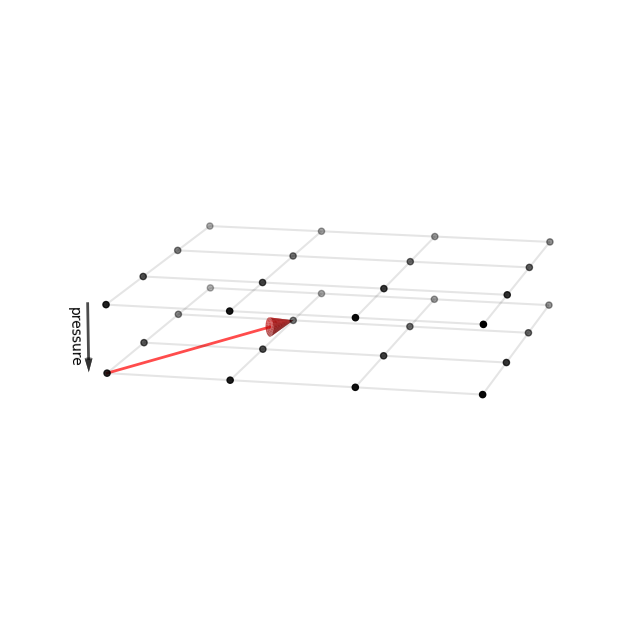

In [177]:
# 3d plot showing a 3d grid

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(8, 8))
# ax.set_proj_type('ortho')

x = np.linspace(0, 10, 4)
y = np.linspace(0, 10, 4)
z = np.linspace(0, 1, 2)
x, y, z = np.meshgrid(x, y, z)
ax.scatter(x, y, z, color="k")

# hide axes
ax.set_axis_off()

# change the perspective
ax.view_init(elev=13, azim=13 - 90)

# equal aspect ratio
ax.set_box_aspect([1, 1, 0.2])

ax.set_zticks([0, 1])
ax.set_zticklabels(["0", "1"])
ax.set_zlabel("p_lev")

# add a 3d grid that connects all points
for i in range(z.shape[2]):
    ax.plot_wireframe(x[:, :, i], y[:, :, i], z[:, :, i], color="k", alpha=0.1)


# add vertical arrow to the left of the plot with label "pressure"
# ax.quiver(-0.5, 0, 1, 0, 0, -1, color="k")
plot_arrow_3d(ax, start=[-0.5, 0, 1], end=[-0.5, 0, 0], color="k", head_length=0.2, head_width=0.1)
ax.text(-1.1, 0, 0.5, "pressure", zdir="z", verticalalignment="center")


# setup transition matrix
tm = np.zeros([2, *x.shape]).astype(int)
tm[:] = -1
tm[0, 0, 0, 0] = 1
tm[1, 0, 0, 0] = 2

# plot arrows between the points in the grid
for k in range(tm.shape[3]):
    for i in range(tm.shape[1]):
        for j in range(tm.shape[2]):
            if tm[0, i, j, k] != -1:
                plot_arrow_3d(
                    ax,
                    start=[x[i, j, k], y[i, j, k], z[i, j, k]],
                    end=[x[i, tm[0, i, j, k], k], y[tm[1, i, j, k], j, k], z[i, j, k]],
                    color="r",
                    head_length=1,
                    head_width=0.15,
                    alpha=0.7,
                )